# Install packages

In [ ]:
!pip install pandas numpy gdown nltk vaderSentiment matplotlib scikit-learn

ERROR: Could not find a version that satisfies the requirement re (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for re


# Download dataset

In [1]:
import pandas as pd
import gdown

In [2]:
file_id = '1Kc7LSMMy72PgKVbsXAPPopQIDpUIZ7l5'
download_url = f'https://drive.google.com/uc?id={file_id}'
output = 'Conversation_Dataset.csv'

gdown.download(download_url, output, quiet=False)

# Load the dataset
df = pd.read_csv(output)

Downloading...
From (original): https://drive.google.com/uc?id=1Kc7LSMMy72PgKVbsXAPPopQIDpUIZ7l5
From (redirected): https://drive.google.com/uc?id=1Kc7LSMMy72PgKVbsXAPPopQIDpUIZ7l5&confirm=t&uuid=135b1171-b2af-48c7-9715-09cb5cd673a2
To: c:\Users\z004ujmt\OneDrive - Siemens AG\personal-projects\conversation-analysis\Conversation_Dataset.csv
100%|██████████| 1.12G/1.12G [06:14<00:00, 2.98MB/s]


In [3]:
df.head(20)

,conversation_id,speaker,date_time,text
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:33+00:00,"Good morning, thank you for calling Union Fina..."
1,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06T14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help manag..."
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you wit..."
3,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06T14:34:01.153846+00:00,Sure thing. My account number is 1234567890.
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:04.384615+00:00,"Thank, thank you for providing that informatio..."
5,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06T14:34:16.846153+00:00,"Well, I'd like to pay my electricity and gas b..."
6,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:25.615384+00:00,"No problem, Della. I can guide you through the..."
7,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06T14:34:40.384615+00:00,"Sure, my electricity provider is GreenYZ Elect..."
8,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:47.307692+00:00,"Greatcellent. Now, I'll need to confirm some i..."
9,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06T14:34:58.846154+00:00,"Okay, it's 1234."


# Question 1 – Feature Engineering & Exploratory data Analysis. Generate insights & trends from the conversations.

In [ ]:
# Text processing libraries
import re
import nltk
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\z004ujmt\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\z004ujmt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\z004ujmt\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### Basic overview

In [5]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nUnique conversations: {df['conversation_id'].nunique()}")
print(f"Unique speakers: {df['speaker'].unique()}")

Dataset shape: (5532112, 4)
Columns: ['conversation_id', 'speaker', 'date_time', 'text']
Data types:
conversation_id    object
speaker            object
date_time          object
text               object
dtype: object

Missing values:
conversation_id      0
speaker              0
date_time            0
text               630
dtype: int64

Unique conversations: 301822
Unique speakers: ['agent' 'Customer']


### Convert datetime

In [6]:
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed')
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df['date'] = df['date_time'].dt.date

In [7]:
print(f"\nDate range: {df['date_time'].min()} to {df['date_time'].max()}")


Date range: 2023-09-01 08:00:03+00:00 to 2023-09-29 18:10:20.307693+00:00


## a) Feature Engineering

Clean and process the text in each data point

In [10]:
# Text preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = str(text).lower()
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply text preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)
df['text_length'] = df['text'].str.len()
df['word_count'] = df['clean_text'].str.split().str.len()

In [ ]:
print(f"\nAverage text length: {df['text_length'].mean()}\nMaximum text length: {df['text_length'].max()}")


Average text length: 125.29646362908053
Maximum text length: 11129


Optimized sentiment analysis using VADER

In [13]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def vectorized_sentiment(texts, batch_size=1000):
    """Apply sentiment analysis to a list of texts in a vectorized manner"""
    # Pre-allocate results array
    results = {
        'compound': np.zeros(len(texts)),
        'pos': np.zeros(len(texts)),
        'neu': np.zeros(len(texts)),
        'neg': np.zeros(len(texts))
    }
    
    # Process texts in batches
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        for j, text in enumerate(batch):
            if pd.isna(text) or text == "":
                continue
            scores = analyzer.polarity_scores(str(text))
            for key in results:
                results[key][i+j] = scores[key]
    
    return pd.DataFrame(results)

In [ ]:
optimal_batch_size = 15000
sentiment_scores = vectorized_sentiment(df['text'].tolist(), batch_size=optimal_batch_size)
df = pd.concat([df, sentiment_scores], axis=1)

In [17]:
df.head()

,conversation_id,speaker,date_time,text,hour,day_of_week,date,length,clean_text,text_length,word_count,compound,pos,neu,neg
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06 14:33:33+00:00,"Good morning, thank you for calling Union Fina...",14,Wednesday,2023-09-06,99,good morning thank you for calling union finan...,99.0,18,0.6597,0.252,0.748,0.0
1,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06 14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help manag...",14,Wednesday,2023-09-06,102,hi monroe my name is della i need help managin...,102.0,20,0.6597,0.231,0.769,0.0
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06 14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you wit...",14,Wednesday,2023-09-06,120,of course della id be happy to help you with t...,120.0,23,0.8271,0.303,0.697,0.0
3,2b6544c382e6423b96785c1a135d8e95,Customer,2023-09-06 14:34:01.153846+00:00,Sure thing. My account number is 1234567890.,14,Wednesday,2023-09-06,44,sure thing my account number is 1234567890,44.0,7,0.3818,0.419,0.581,0.0
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06 14:34:04.384615+00:00,"Thank, thank you for providing that informatio...",14,Wednesday,2023-09-06,169,thank thank you for providing that information...,169.0,27,0.7579,0.238,0.762,0.0


Conversation-level features


In [34]:
# Create a slim dataFrame for computing features
slim_df = df[['conversation_id', 'speaker', 'date_time', 'text_length', 'word_count', 'compound']].copy()

basic_features = slim_df.groupby('conversation_id').agg({
    'text_length': 'mean',
    'word_count': 'sum',
    'date_time': ['min', 'max', 'count']
})

# Flatten multi-level columns and rename for clarity
basic_features.columns = ['_'.join(col).strip() for col in basic_features.columns]
basic_features = basic_features.reset_index()

basic_features = basic_features.rename(columns={
    'text_length_mean': 'avg_message_length',
    'word_count_sum': 'total_words',
    'date_time_min': 'start_time',
    'date_time_max': 'end_time',
    'date_time_count': 'total_messages'
})

In [35]:
# Features: duration and messages per minute
basic_features['duration_minutes'] = (
    (basic_features['end_time'] - basic_features['start_time']).dt.total_seconds() / 60
)
basic_features['messages_per_minute'] = (
    basic_features['total_messages'] / basic_features['duration_minutes'].clip(lower=1)
)

In [36]:
# Features: tart hour and day of week
basic_features['start_hour'] = basic_features['start_time'].dt.hour
basic_features['day_of_week'] = basic_features['start_time'].dt.day_name()

In [37]:
# Features: Metrics by Speaker
## Speaker = Customer
client_metrics = slim_df[slim_df['speaker'] == 'Customer'].groupby('conversation_id').agg({
    'compound': 'mean',
    'speaker': 'count'
}).rename(columns={
    'compound': 'avg_customer_sentiment',
    'speaker': 'customer_messages'
})

## Speaker = agent
agent_metrics = slim_df[slim_df['speaker'] == 'agent'].groupby('conversation_id').agg({
    'compound': 'mean',
    'speaker': 'count'
}).rename(columns={
    'compound': 'avg_agent_sentiment',
    'speaker': 'agent_messages'
})

## Merge speaker metrics to features dataframe
features_df = basic_features.merge(client_metrics, on='conversation_id', how='left')
features_df = features_df.merge(agent_metrics, on='conversation_id', how='left')

## Fill missing values
features_df['avg_customer_sentiment'] = features_df['avg_customer_sentiment'].fillna(0)
features_df['avg_agent_sentiment'] = features_df['avg_agent_sentiment'].fillna(0)
features_df['customer_messages'] = features_df['customer_messages'].fillna(0).astype(int)
features_df['agent_messages'] = features_df['agent_messages'].fillna(0).astype(int)

In [38]:
# Features: Response Time
## Identify client-agent message pairs for calculating the time difference
message_pairs_df = slim_df[['conversation_id', 'speaker', 'date_time']].copy().sort_values(['conversation_id', 'date_time'])
message_pairs_df['prev_speaker'] = message_pairs_df.groupby('conversation_id')['speaker'].shift(1)
message_pairs_df['is_response'] = (message_pairs_df['prev_speaker'] == 'Customer') & (message_pairs_df['speaker'] == 'agent')

## Calculate response time for each client-agent message pair
message_pairs_df['prev_time'] = message_pairs_df.groupby('conversation_id')['date_time'].shift(1)
message_pairs_df['response_time'] = np.where(
    message_pairs_df['is_response'],
    (message_pairs_df['date_time'] - message_pairs_df['prev_time']).dt.total_seconds(),
    np.nan
)

## Calculate the average response time for each client-agent message pair
response_times_df = message_pairs_df[message_pairs_df['is_response']].groupby('conversation_id')['response_time'].mean().reset_index()

## Convert the dataframe to a dictionary for mapping 
response_times = dict(zip(response_times_df['conversation_id'], response_times_df['response_time']))

## Merge it with the features dataframe
features_df['avg_response_time_seconds'] = features_df['conversation_id'].map(response_times).fillna(0)


In [39]:
# Copy to a new dataframe for conversation-level features
conv_df = features_df.copy()

In [40]:
conv_df.head()

,conversation_id,avg_message_length,total_words,start_time,end_time,total_messages,duration_minutes,messages_per_minute,start_hour,day_of_week,avg_customer_sentiment,customer_messages,avg_agent_sentiment,agent_messages,avg_response_time_seconds
0,00001491bf0c4c19bd6f242933e35434,117.714286,447,2023-09-09 11:33:44+00:00,2023-09-09 11:37:08.461541+00:00,21,3.407692,6.162528,11,Saturday,0.250250,10,0.447127,11,6.553846
1,00002670fe084aea855ef231e6aacca5,91.250000,336,2023-09-12 16:07:00+00:00,2023-09-12 16:09:34.153847+00:00,20,2.569231,7.784431,16,Tuesday,0.524350,10,0.432920,10,5.723077
2,0000316d4a7d40279611d40be8031a6a,95.615385,233,2023-09-21 08:34:49+00:00,2023-09-21 08:36:34.692307+00:00,13,1.761538,7.379913,8,Thursday,0.309217,6,0.500529,7,6.153846
3,000049eb72dd4ab6a1ee4b00983b306f,142.823529,428,2023-09-08 12:07:56+00:00,2023-09-08 12:11:08.923077+00:00,17,3.215385,5.287081,12,Friday,0.066600,8,0.413289,9,8.250000
4,000053abe5674e569cbb91f618069ddc,126.800000,325,2023-09-22 10:58:20+00:00,2023-09-22 11:00:49.076922+00:00,15,2.484615,6.037152,10,Friday,0.519029,7,0.452475,8,6.461538


In [41]:
print(f"Features: {list(conv_df.columns)}")

Features: ['conversation_id', 'avg_message_length', 'total_words', 'start_time', 'end_time', 'total_messages', 'duration_minutes', 'messages_per_minute', 'start_hour', 'day_of_week', 'avg_customer_sentiment', 'customer_messages', 'avg_agent_sentiment', 'agent_messages', 'avg_response_time_seconds']


## b) Exploratory data analysis & Insights

In [42]:
import matplotlib.pyplot as plt


### Conversation-level visualizations

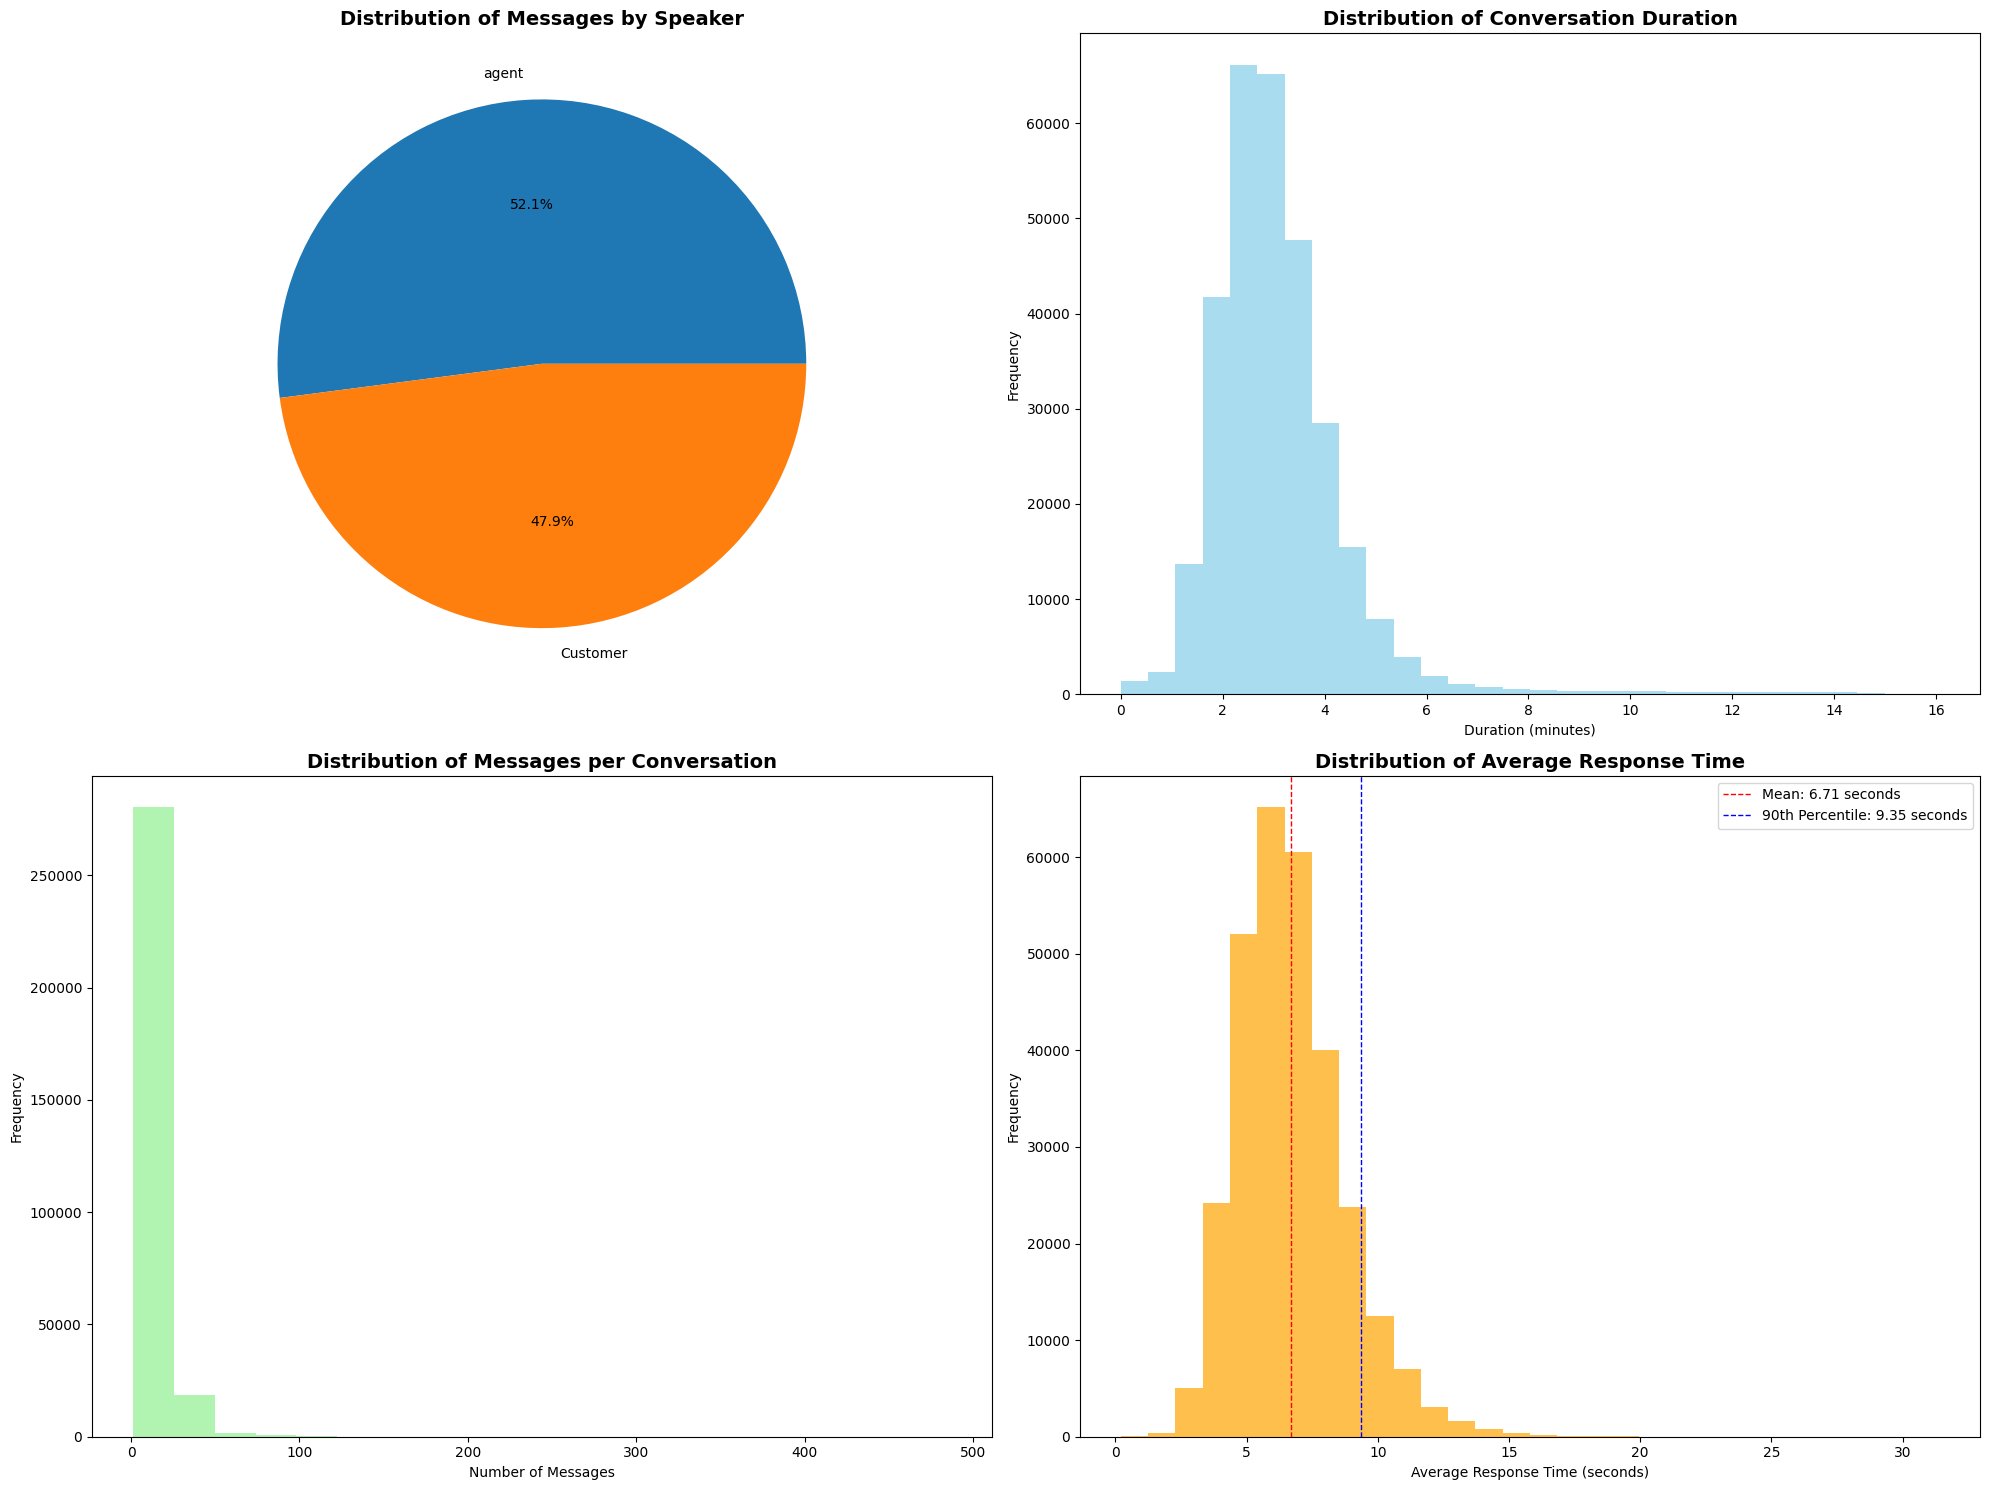

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Message distribution by speaker
speaker_counts = df['speaker'].value_counts()
axes[0, 0].pie(speaker_counts.values, labels=speaker_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Distribution of Messages by Speaker', fontsize=14, fontweight='bold')

# Conversation duration distribution
axes[0, 1].hist(conv_df['duration_minutes'], bins=30, alpha=0.7, color='skyblue')
axes[0, 1].set_xlabel('Duration (minutes)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Conversation Duration', fontsize=14, fontweight='bold')

# Messages per conversation
axes[1, 0].hist(conv_df['total_messages'], bins=20, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Number of Messages')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Messages per Conversation', fontsize=14, fontweight='bold')

# Response time distribution
response_times_filtered = conv_df[conv_df['avg_response_time_seconds'] > 0]['avg_response_time_seconds']
axes[1, 1].hist(response_times_filtered, bins=30, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Average Response Time (seconds)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Average Response Time', fontsize=14, fontweight='bold')

## Add a vertical line for the mean response time
mean_response_time = response_times_filtered.mean()
axes[1, 1].axvline(mean_response_time, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_response_time:.2f} seconds')
## Add a line for the 90th percentile time
ninetieth_percentile_response_time = response_times_filtered.quantile(0.9)
axes[1, 1].axvline(ninetieth_percentile_response_time, color='blue', linestyle='dashed', linewidth=1, label=f'90th Percentile: {ninetieth_percentile_response_time:.2f} seconds')
## Add legend
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Sentiment analysis visualizations

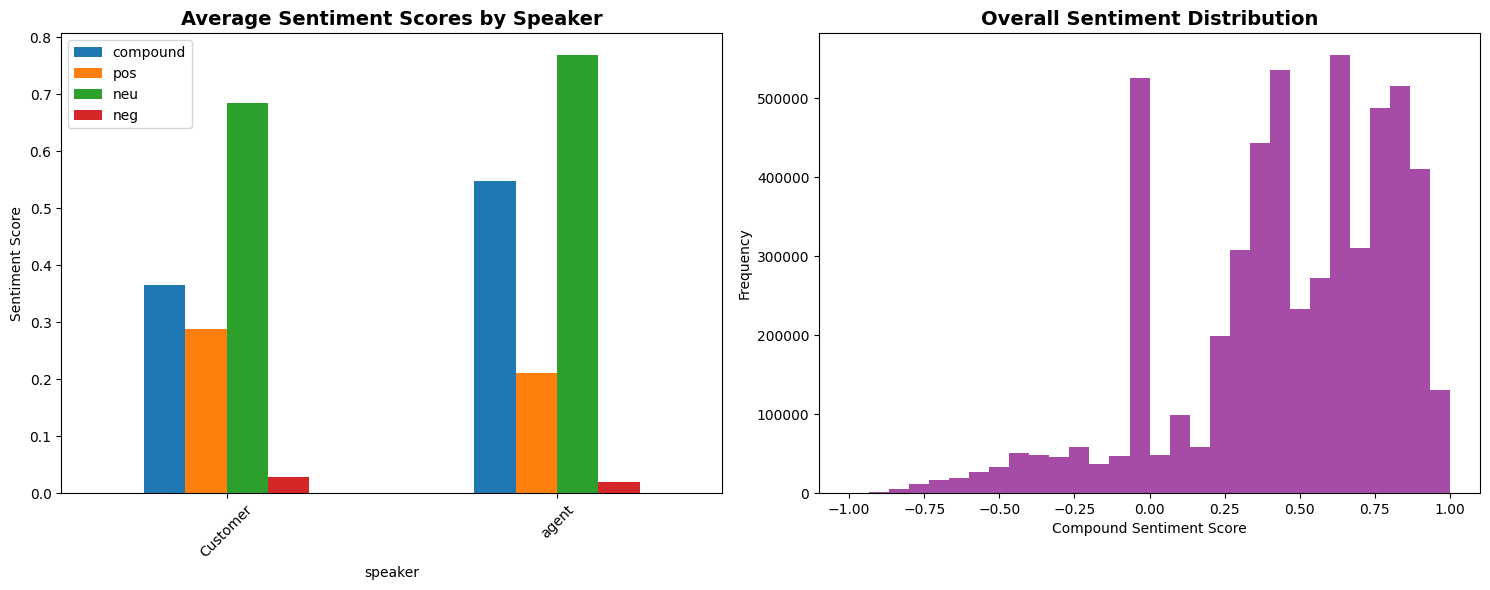

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Customer vs Agent sentiment
sentiment_by_speaker = df.groupby('speaker')[['compound', 'pos', 'neu', 'neg']].mean()
sentiment_by_speaker.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Sentiment Scores by Speaker', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sentiment Score')
axes[0].tick_params(axis='x', rotation=45)

# Sentiment distribution
axes[1].hist(df['compound'], bins=30, alpha=0.7, color='purple')
axes[1].set_xlabel('Compound Sentiment Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Temporal analysis

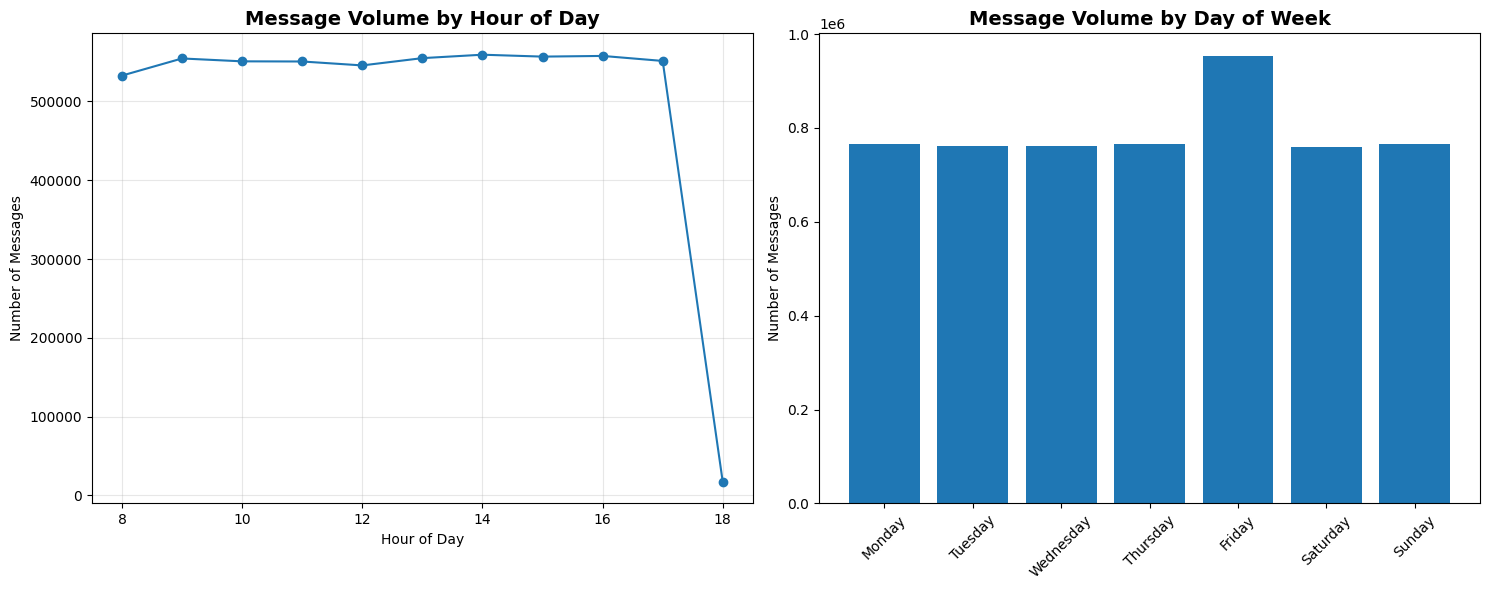

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Messages by hour
hourly_messages = df.groupby('hour').size()
axes[0].plot(hourly_messages.index, hourly_messages.values, marker='o')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Messages')
axes[0].set_title('Message Volume by Hour of Day', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Messages by day of week
daily_messages = df.groupby('day_of_week').size()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_messages = daily_messages.reindex(day_order)
axes[1].bar(range(len(daily_messages)), daily_messages.values)
axes[1].set_xticks(range(len(daily_messages)))
axes[1].set_xticklabels(daily_messages.index, rotation=45)
axes[1].set_ylabel('Number of Messages')
axes[1].set_title('Message Volume by Day of Week', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Key insights

#### Insight 1: Peak activity times

In [ ]:
peak_hours = hourly_messages.nlargest(3)
print(
    "INSIGHT 1: Peak Activity Times"
    f"\nPeak hours and messages: {list(peak_hours.index)} Hours: {[int(i) for i in list(peak_hours.values)]} messages"
    "\nRecommendation: Deploy more bot resources during these hours"
)

INSIGHT 1: Peak Activity Times
Peak hours and messages: [14, 16, 15] Hours: [559331, 557771, 556909] messages
Recommendation: Deploy more bot resources during these hours


#### Insight 2: Conversation length patterns

In [64]:
avg_messages = conv_df['total_messages'].mean()
long_conversations = len(conv_df[conv_df['total_messages'] > avg_messages * 1.5])
print(
    "\nINSIGHT 2: Conversation Length Patterns"
    f"\nAverage messages per conversation: {avg_messages:.1f}"
    f"\nLong conversations (>50% above average): {long_conversations} ({long_conversations/len(conv_df)*100:.1f}%)"
    "\nRecommendation: Identify patterns in long conversations to improve bot efficiency"
)


INSIGHT 2: Conversation Length Patterns
Average messages per conversation: 18.3
Long conversations (>50% above average): 14617 (4.8%)
Recommendation: Identify patterns in long conversations to improve bot efficiency


#### Insight 3: Response time analysis

In [75]:
fast_responses = len(conv_df[conv_df['avg_response_time_seconds'] <= round(mean_response_time)])
slow_responses = len(conv_df[conv_df['avg_response_time_seconds'] > round(ninetieth_percentile_response_time)])
print(
    "\nINSIGHT 3: Response Time Analysis"
    f"\nFast responses (≤{mean_response_time:.2f} sec): {fast_responses} ({fast_responses/len(conv_df)*100:.1f}%)"
    f"\nSlow responses (>{ninetieth_percentile_response_time:.2f} sec): {slow_responses} ({slow_responses/len(conv_df)*100:.1f}%)"
    f"\nAverage response time: {mean_response_time:.2f} seconds"
    f"\nRecommendation: Optimize bot to achieve sub-{mean_response_time:.2f} second response times"
)


INSIGHT 3: Response Time Analysis
Fast responses (≤6.71 sec): 186666 (61.8%)
Slow responses (>9.35 sec): 36786 (12.2%)
Average response time: 6.71 seconds
Recommendation: Optimize bot to achieve sub-6.71 second response times


#### Insight 4: Sentiment patterns

In [77]:
negative_sentiment_conversations = len(conv_df[conv_df['avg_customer_sentiment'] < -0.1])
positive_sentiment_conversations = len(conv_df[conv_df['avg_customer_sentiment'] > 0.1])
print(
    "\nINSIGHT 4: Customer Sentiment Patterns"
    f"\nConversations with negative customer sentiment: {negative_sentiment_conversations} ({negative_sentiment_conversations/len(conv_df)*100:.1f}%)"
    f"\nConversations with positive customer sentiment: {positive_sentiment_conversations} ({positive_sentiment_conversations/len(conv_df)*100:.1f}%)"
    "\nRecommendation: Implement sentiment-aware responses and escalation triggers"
)


INSIGHT 4: Customer Sentiment Patterns
Conversations with negative customer sentiment: 1940 (0.6%)
Conversations with positive customer sentiment: 280370 (92.9%)
Recommendation: Implement sentiment-aware responses and escalation triggers


#### Insight 5: Message complexity

In [78]:
complex_messages = len(df[df['word_count'] > df['word_count'].quantile(0.9)])
simple_messages = len(df[df['word_count'] < df['word_count'].quantile(0.25)])
print(
    "\nINSIGHT 5: Message Complexity Analysis"
    f"\nAverage words per message: {df['word_count'].mean():.1f}"
    f"\nComplex messages (top 10%): {complex_messages} with avg {df[df['word_count'] > df['word_count'].quantile(0.9)]['word_count'].mean():.1f} words"
    f"\nSimple messages (bottom 25%): {simple_messages} with avg {df[df['word_count'] < df['word_count'].quantile(0.25)]['word_count'].mean():.1f} words"
    "\nRecommendation: Train bot to handle varying message complexity levels"
)


INSIGHT 5: Message Complexity Analysis
Average words per message: 22.2
Complex messages (top 10%): 526031 with avg 60.3 words
Simple messages (bottom 25%): 1362363 with avg 5.3 words
Recommendation: Train bot to handle varying message complexity levels


# Question 2 - Unsupervised Customer Satisfaction Scoring

In [212]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

## Create features

In [159]:
slim_df = df[['conversation_id', 'speaker', 'date_time', 'compound', 'clean_text']].copy().sort_values(['conversation_id', 'date_time'])

In [160]:
# Features: Response Time
## Identify client-agent message pairs for calculating the time difference
slim_df['prev_speaker'] = slim_df.groupby('conversation_id')['speaker'].shift(1)
slim_df['is_response'] = (slim_df['prev_speaker'] == 'Customer') & (slim_df['speaker'] == 'agent')

## Calculate response time for each client-agent message pair
slim_df['prev_time'] = slim_df.groupby('conversation_id')['date_time'].shift(1)
slim_df['response_time'] = np.where(
    slim_df['is_response'],
    (slim_df['date_time'] - slim_df['prev_time']).dt.total_seconds(),
    np.nan
)

## Calculate the average response time for each client-agent message pair
response_times_summary = slim_df[slim_df['is_response']].groupby('conversation_id').agg({
    'response_time': ['mean', 'max']
}).reset_index()

# Flatten column names
response_times_summary.columns = ['_'.join(col).strip() if col[1] else col[0] for col in response_times_summary.columns]

# Create response time lookup dictionaries
avg_response_times = dict(zip(response_times_summary['conversation_id'], response_times_summary['response_time_mean']))
max_response_times = dict(zip(response_times_summary['conversation_id'], response_times_summary['response_time_max']))

In [161]:
# Features: Basic conversation metrics
basic_metrics = slim_df.groupby('conversation_id').agg({
    'date_time': ['min', 'max', 'count']
}).reset_index()

# Flatten multi-level columns and rename for clarity
basic_metrics.columns = ['_'.join(col).strip() if col[1] else col[0] for col in basic_metrics.columns]
basic_metrics = basic_metrics.reset_index()

basic_metrics['duration_minutes'] = (
    (basic_metrics['date_time_max'] - basic_metrics['date_time_min']).dt.total_seconds() / 60
)

In [162]:
# Features: Customer-specific metrics
customer_df = slim_df[slim_df['speaker'] == 'Customer']
# Get first and last sentiment per conversation
customer_first = customer_df.groupby('conversation_id').first().reset_index()
customer_last = customer_df.groupby('conversation_id').last().reset_index()

# Count customer messages per conversation
customer_count = customer_df.groupby('conversation_id').size().reset_index(name='customer_messages')

# Calculate average customer sentiment
customer_sentiment = customer_df.groupby('conversation_id')['compound'].mean().reset_index(name='avg_customer_sentiment')

In [163]:
# Features: Resolution indicators
# Get text of last 3 messages per conversation
slim_df['msg_rank'] = slim_df.groupby('conversation_id')['date_time'].rank(method='first', ascending=False)
last_msgs = slim_df[slim_df['msg_rank'] <= 3].groupby('conversation_id')['clean_text'].apply(' '.join).reset_index()
last_msgs.columns = ['conversation_id', 'last_messages']

# Define resolution and escalation keywords
resolution_keywords = ['thank', 'thanks', 'solved', 'resolved', 'helpful', 'great', 'perfect', 'excellent']
escalation_keywords = ['frustrated', 'angry', 'complaint', 'manager', 'supervisor', 'unacceptable']

# Create vectorized functions to count keyword occurrences
def count_keywords(text, keywords):
    if pd.isna(text):
        return 0
    return sum(1 for keyword in keywords if keyword in text.lower())

# Apply functions to count keywords
last_msgs['resolution_score'] = last_msgs['last_messages'].apply(lambda x: count_keywords(x, resolution_keywords))
last_msgs['escalation_score'] = last_msgs['last_messages'].apply(lambda x: count_keywords(x, escalation_keywords))


In [164]:
# Features: Sentiment trend
# Calculate sentiment trend (difference between last and first customer message)
sentiment_trend = pd.DataFrame({
    'conversation_id': customer_first['conversation_id'],
    'sentiment_trend': customer_last['compound'] - customer_first['compound'],
    'final_sentiment': customer_last['compound']
})

In [165]:
# Combine all features into a single DataFrame
satisfaction_df = basic_metrics.rename(columns={
    'date_time_count': 'total_messages',
})
satisfaction_df = satisfaction_df.merge(customer_count, on='conversation_id', how='left')
satisfaction_df['efficiency_score'] = 1 / (satisfaction_df['customer_messages'] + 1)

satisfaction_df = satisfaction_df.merge(customer_sentiment, on='conversation_id', how='left')
satisfaction_df = satisfaction_df.merge(sentiment_trend, on='conversation_id', how='left')

satisfaction_df = satisfaction_df.merge(
    last_msgs[['conversation_id', 'resolution_score', 'escalation_score']], 
    on='conversation_id', 
    how='left'
)

satisfaction_df = satisfaction_df.merge(
    response_times_summary[['conversation_id', 'response_time_mean', 'response_time_max']], 
    on='conversation_id', 
    how='left'
)
satisfaction_df = satisfaction_df.rename(columns={
    'response_time_mean': 'avg_response_time',
    'response_time_max': 'max_response_time'
})

In [175]:
# Fill NaN values
satisfaction_df = satisfaction_df.fillna({
    'customer_messages': 0,
    'avg_customer_sentiment': 0,
    'sentiment_trend': 0,
    'final_sentiment': 0,
    'resolution_score': 0,
    'escalation_score': 0,
    'avg_response_time': 0,
    'max_response_time': 0,
    'efficiency_score': 1.0
})

In [167]:
# Clean up columns and select final features
final_cols = [
    'conversation_id', 'duration_minutes', 'total_messages', 'customer_messages',
    'sentiment_trend', 'final_sentiment', 'avg_response_time', 'max_response_time',
    'resolution_score', 'escalation_score', 'efficiency_score', 'avg_customer_sentiment'
]

satisfaction_df = satisfaction_df[final_cols]

## Normalize features for scoring


In [168]:
scaler = StandardScaler()
feature_cols = ['sentiment_trend', 'final_sentiment', 'avg_response_time', 'max_response_time', 
                'resolution_score', 'escalation_score', 'efficiency_score', 'avg_customer_sentiment']

satisfaction_df[feature_cols] = scaler.fit_transform(satisfaction_df[feature_cols])

In [169]:
print(f"Features: {list(satisfaction_df.columns)}")

Features: ['conversation_id', 'duration_minutes', 'total_messages', 'customer_messages', 'sentiment_trend', 'final_sentiment', 'avg_response_time', 'max_response_time', 'resolution_score', 'escalation_score', 'efficiency_score', 'avg_customer_sentiment']


## Create composite satisfaction score

In [ ]:
def calculate_satisfaction_score(row):
    """Calculate satisfaction score based on multiple factors"""
    # the coefficients are chosen based on their relative importance that is based on domain knowledge
    score = 0
    
    # Positive factors (higher is better)
    score += row['sentiment_trend'] * 0.2  # Sentiment improvement
    score += row['final_sentiment'] * 0.25  # Final sentiment
    score += row['resolution_score'] * 0.15  # Resolution keywords
    score += row['efficiency_score'] * 0.1  # Conversation efficiency
    score += row['avg_customer_sentiment'] * 0.2  # Overall customer sentiment
    
    # Negative factors (lower is better)
    score -= row['avg_response_time'] * 0.05  # Response time
    score -= row['max_response_time'] * 0.03  # Max response time
    score -= row['escalation_score'] * 0.02  # Escalation keywords
    
    return score

In [171]:
satisfaction_df['satisfaction_score'] = satisfaction_df.apply(calculate_satisfaction_score, axis=1)

## Categorize satisfaction levels by quantiles

In [172]:
satisfaction_df['satisfaction_category'] = pd.cut(
    satisfaction_df['satisfaction_score'], 
    bins=3, 
    labels=['Not Satisfied', 'Neutral', 'Satisfied'],
    include_lowest=True
)

In [186]:
satisfaction_df

,conversation_id,duration_minutes,total_messages,customer_messages,sentiment_trend,final_sentiment,avg_response_time,max_response_time,resolution_score,escalation_score,efficiency_score,avg_customer_sentiment,satisfaction_score,satisfaction_category,cluster
0,00001491bf0c4c19bd6f242933e35434,3.407692,21,10.0,-2.070634,-1.429033,-0.021263,0.498076,-0.404799,-0.080999,-0.604542,-0.694287,-1.043676,Neutral,1
1,00002670fe084aea855ef231e6aacca5,2.569231,20,10.0,0.862703,0.237411,-0.400576,0.413698,0.780881,-0.080999,-0.604542,0.940328,0.485875,Neutral,0
2,0000316d4a7d40279611d40be8031a6a,1.761538,13,6.0,0.677937,0.434932,-0.203895,-0.092570,0.780881,-0.080999,0.993015,-0.342635,0.406819,Neutral,0
3,000049eb72dd4ab6a1ee4b00983b306f,3.215385,17,8.0,-0.995526,-1.429033,0.753166,0.244942,-0.404799,-0.080999,0.016730,-1.789497,-1.016696,Neutral,1
4,000053abe5674e569cbb91f618069ddc,2.484615,15,7.0,1.227067,1.067228,-0.063409,-0.683215,-0.404799,-0.080999,0.443855,0.908593,0.702891,Neutral,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301817,ffff960e07da44b0af951bd5896ffb6f,1.484615,15,6.0,0.734131,0.237411,-1.117055,-1.189482,-0.404799,-0.080999,0.993015,0.101651,0.358248,Neutral,0
301818,ffffc406dc144b33acca5991a82064c4,2.338462,13,6.0,1.348221,0.237411,0.112199,-0.092570,0.780881,-0.080999,0.993015,0.036250,0.551468,Neutral,0
301819,ffffe326683642218f4c11622f841a78,2.784615,17,7.0,2.801179,1.220855,0.598882,-0.008192,0.780881,-0.080999,0.443855,-1.512873,0.696314,Neutral,0
301820,fffff00598be4f77b476c369ca0b2c21,2.784615,21,10.0,-1.159164,-1.429033,-0.231992,-0.683215,-1.590479,-0.080999,-0.604542,-0.903787,-1.035158,Neutral,1


## Categorize satisfaction levels by clusters

In [174]:
satisfaction_df[feature_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301822 entries, 0 to 301821
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   sentiment_trend         301822 non-null  float64
 1   final_sentiment         301822 non-null  float64
 2   avg_response_time       301822 non-null  float64
 3   max_response_time       301822 non-null  float64
 4   resolution_score        301822 non-null  float64
 5   escalation_score        301822 non-null  float64
 6   efficiency_score        298498 non-null  float64
 7   avg_customer_sentiment  301822 non-null  float64
dtypes: float64(8)
memory usage: 18.4 MB


In [177]:
kmeans = KMeans(n_clusters=3, random_state=42)
satisfaction_df['cluster'] = kmeans.fit_predict(satisfaction_df[feature_cols])

# Map clusters to satisfaction levels based on average scores
cluster_means = satisfaction_df.groupby('cluster')['satisfaction_score'].mean()


In [192]:
cluster_mapping = {
    cluster_means.idxmin(): 'Not Satisfied',
    cluster_means.idxmax(): 'Satisfied',
    cluster_means.sort_values().index[1]: 'Neutral'
}
satisfaction_df['satisfaction_category_clustered'] = satisfaction_df['cluster'].map(cluster_mapping)

In [193]:
satisfaction_df

,conversation_id,duration_minutes,total_messages,customer_messages,sentiment_trend,final_sentiment,avg_response_time,max_response_time,resolution_score,escalation_score,efficiency_score,avg_customer_sentiment,satisfaction_score,satisfaction_category,cluster,satisfaction_category_clustered
0,00001491bf0c4c19bd6f242933e35434,3.407692,21,10.0,-2.070634,-1.429033,-0.021263,0.498076,-0.404799,-0.080999,-0.604542,-0.694287,-1.043676,Neutral,1,Not Satisfied
1,00002670fe084aea855ef231e6aacca5,2.569231,20,10.0,0.862703,0.237411,-0.400576,0.413698,0.780881,-0.080999,-0.604542,0.940328,0.485875,Neutral,0,Satisfied
2,0000316d4a7d40279611d40be8031a6a,1.761538,13,6.0,0.677937,0.434932,-0.203895,-0.092570,0.780881,-0.080999,0.993015,-0.342635,0.406819,Neutral,0,Satisfied
3,000049eb72dd4ab6a1ee4b00983b306f,3.215385,17,8.0,-0.995526,-1.429033,0.753166,0.244942,-0.404799,-0.080999,0.016730,-1.789497,-1.016696,Neutral,1,Not Satisfied
4,000053abe5674e569cbb91f618069ddc,2.484615,15,7.0,1.227067,1.067228,-0.063409,-0.683215,-0.404799,-0.080999,0.443855,0.908593,0.702891,Neutral,0,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301817,ffff960e07da44b0af951bd5896ffb6f,1.484615,15,6.0,0.734131,0.237411,-1.117055,-1.189482,-0.404799,-0.080999,0.993015,0.101651,0.358248,Neutral,0,Satisfied
301818,ffffc406dc144b33acca5991a82064c4,2.338462,13,6.0,1.348221,0.237411,0.112199,-0.092570,0.780881,-0.080999,0.993015,0.036250,0.551468,Neutral,0,Satisfied
301819,ffffe326683642218f4c11622f841a78,2.784615,17,7.0,2.801179,1.220855,0.598882,-0.008192,0.780881,-0.080999,0.443855,-1.512873,0.696314,Neutral,0,Satisfied
301820,fffff00598be4f77b476c369ca0b2c21,2.784615,21,10.0,-1.159164,-1.429033,-0.231992,-0.683215,-1.590479,-0.080999,-0.604542,-0.903787,-1.035158,Neutral,1,Not Satisfied


In [194]:
print("\nSatisfaction Distribution (Score-based):")
print(satisfaction_df['satisfaction_category'].value_counts())
print("Percentages:")
print(satisfaction_df['satisfaction_category'].value_counts(normalize=True) * 100)

print("\nSatisfaction Distribution (Cluster-based):")
print(satisfaction_df['satisfaction_category_clustered'].value_counts())
print("Percentages:")
print(satisfaction_df['satisfaction_category_clustered'].value_counts(normalize=True) * 100)


Satisfaction Distribution (Score-based):
satisfaction_category
Neutral          283744
Satisfied          9587
Not Satisfied      5167
Name: count, dtype: int64
Percentages:
satisfaction_category
Neutral          95.057253
Satisfied         3.211747
Not Satisfied     1.731000
Name: proportion, dtype: float64

Satisfaction Distribution (Cluster-based):
satisfaction_category_clustered
Satisfied        143856
Not Satisfied     79623
Neutral           78343
Name: count, dtype: int64
Percentages:
satisfaction_category_clustered
Satisfied        47.662530
Not Satisfied    26.380781
Neutral          25.956690
Name: proportion, dtype: float64


## Visualize satisfaction results

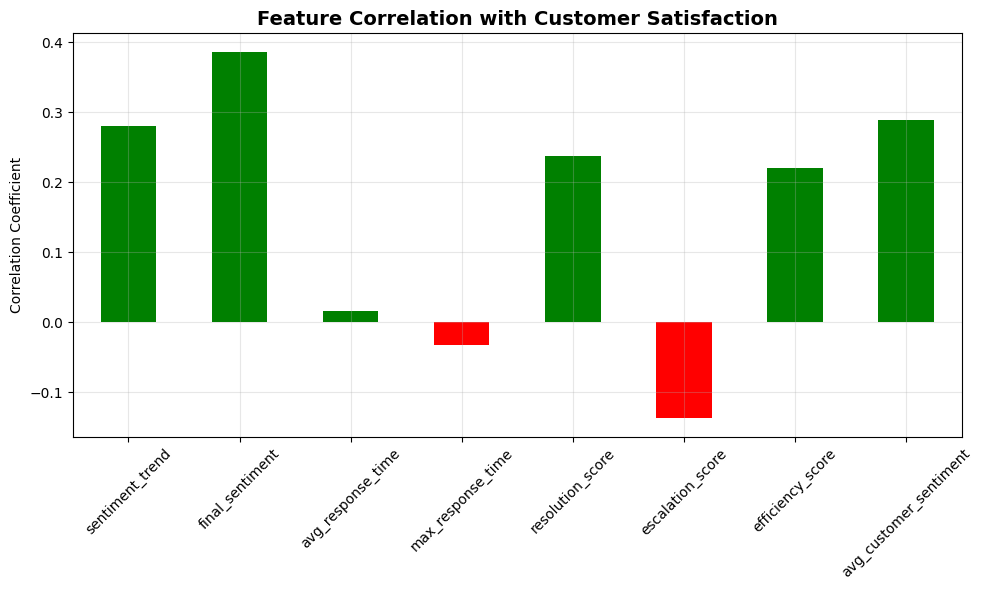

In [ ]:
# Feature correlation with satisfaction
satisfaction_df['satisfaction_numeric'] = satisfaction_df['satisfaction_category'].map(
    {'Not Satisfied': 0, 'Neutral': 1, 'Satisfied': 2}
)

correlations = satisfaction_df[feature_cols + ['satisfaction_numeric']].corr()['satisfaction_numeric'].drop('satisfaction_numeric')

C:\Users\z004ujmt\AppData\Local\Temp\ipykernel_9956\2518313824.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(boxplot_data, labels=satisfaction_categories)


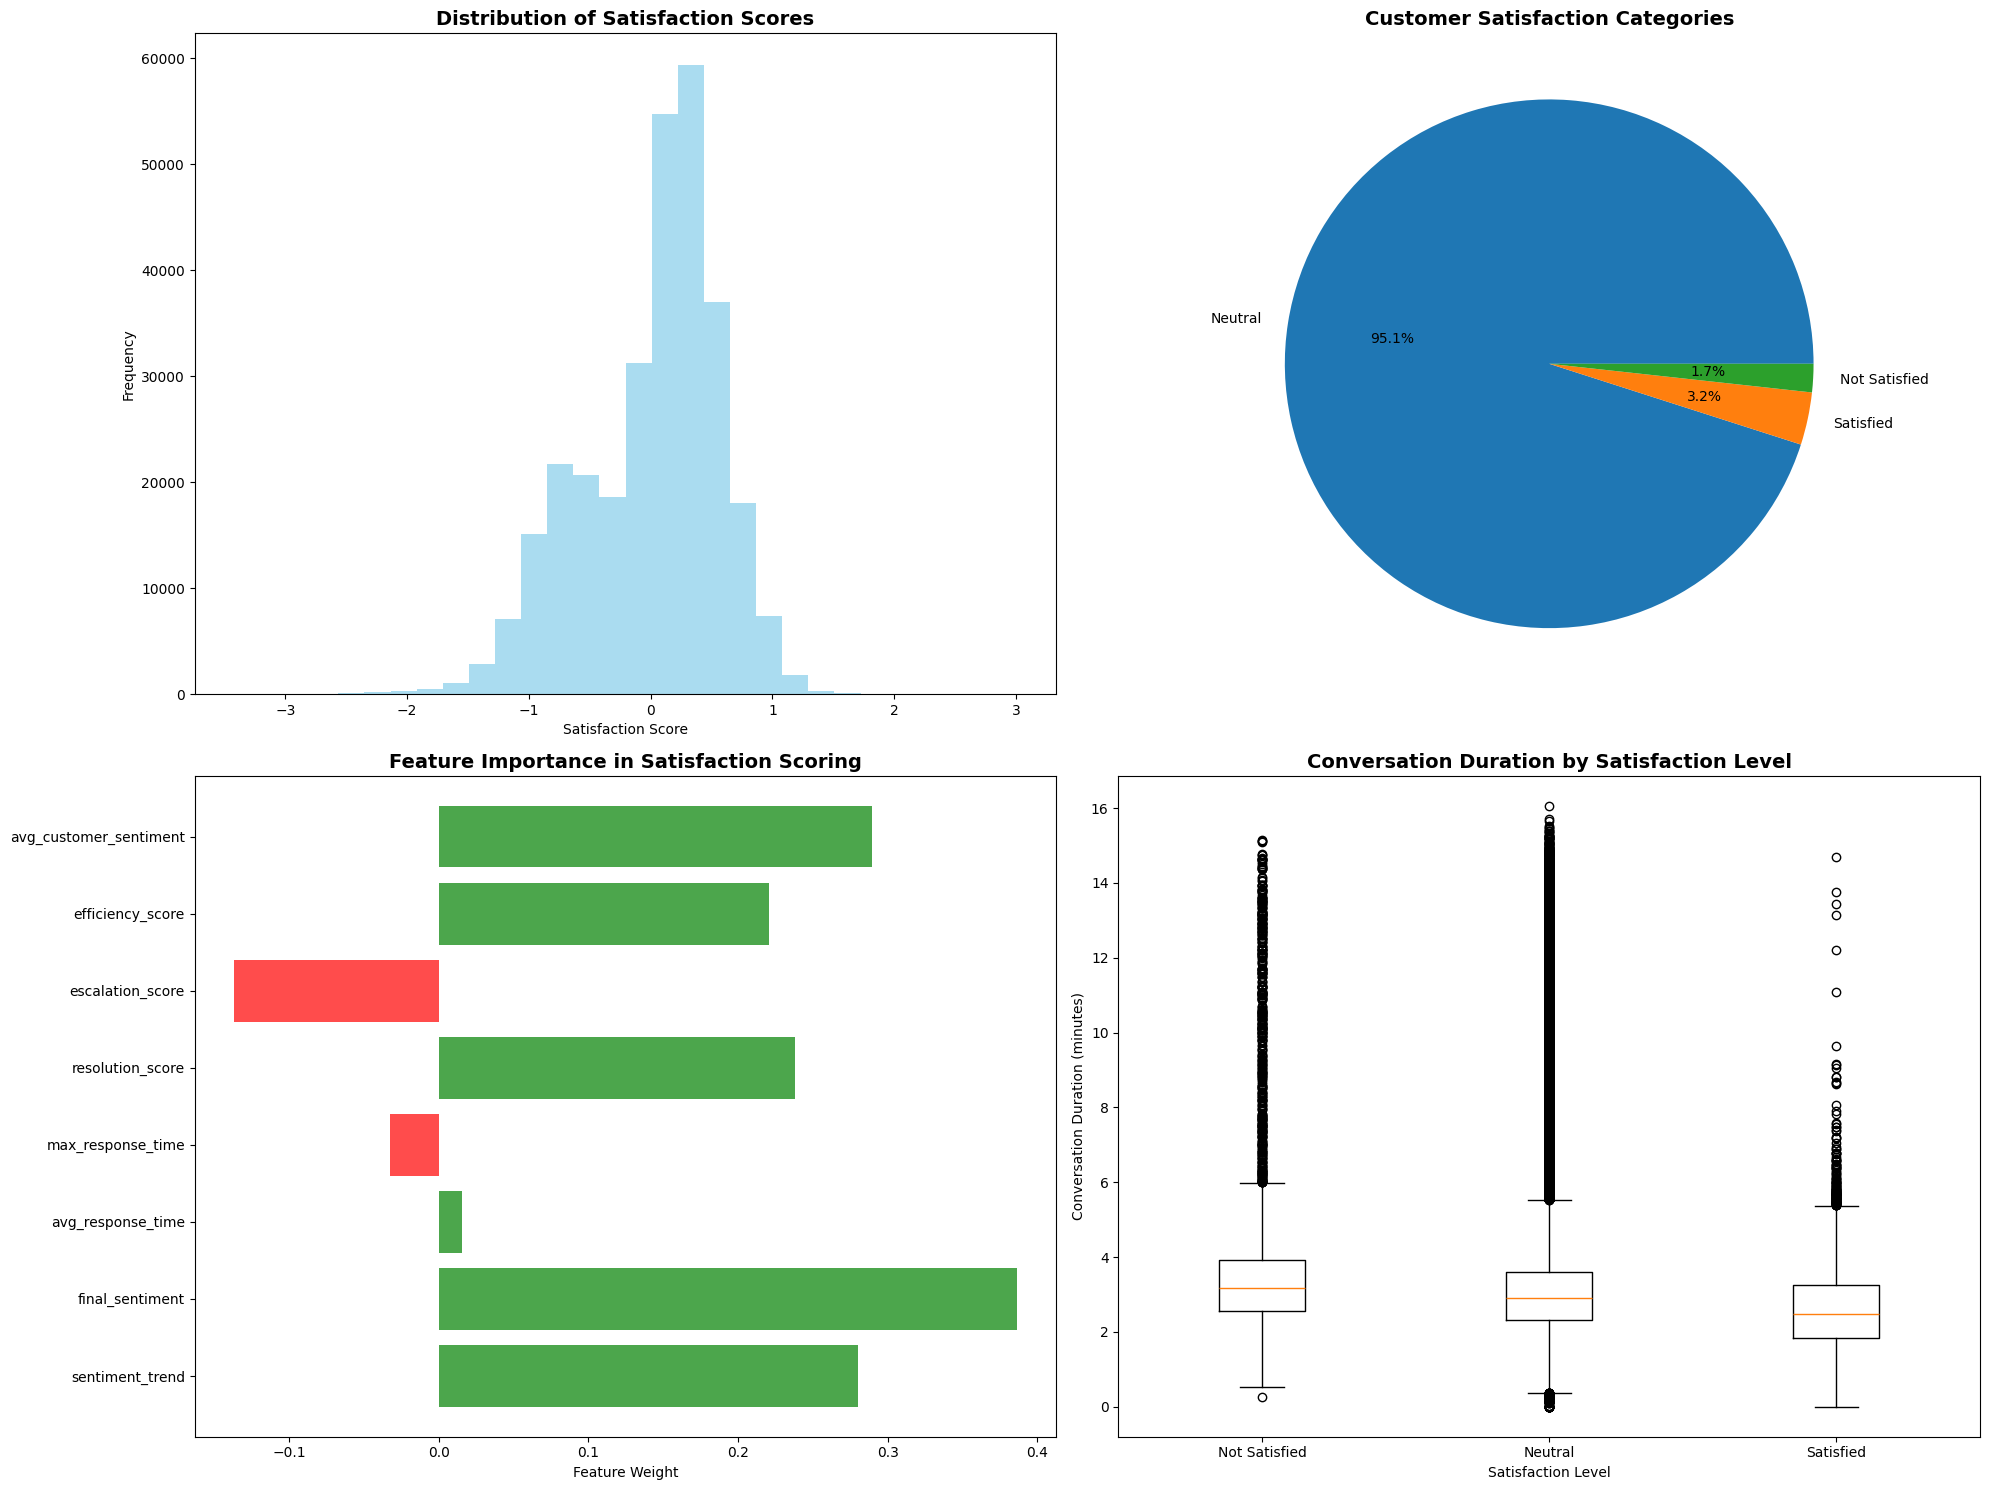

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Satisfaction score distribution
axes[0, 0].hist(satisfaction_df['satisfaction_score'], bins=30, alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Satisfaction Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Satisfaction Scores', fontsize=14, fontweight='bold')

# Satisfaction categories
satisfaction_counts = satisfaction_df['satisfaction_category'].value_counts()
axes[0, 1].pie(satisfaction_counts.values, labels=satisfaction_counts.index, autopct='%1.1f%%')
axes[0, 1].set_title('Customer Satisfaction Categories', fontsize=14, fontweight='bold')

# Feature importance for satisfaction
feature_importance = correlations.to_dict()

features = list(feature_importance.keys())
importance = list(feature_importance.values())
colors = ['green' if imp > 0 else 'red' for imp in importance]

axes[1, 0].barh(features, importance, color=colors, alpha=0.7)
axes[1, 0].set_xlabel('Feature Weight')
axes[1, 0].set_title('Feature Importance in Satisfaction Scoring', fontsize=14, fontweight='bold')

# Satisfaction vs Duration
satisfaction_categories = ['Not Satisfied', 'Neutral', 'Satisfied']
boxplot_data = [satisfaction_df[satisfaction_df['satisfaction_category'] == cat]['duration_minutes'] 
                for cat in satisfaction_categories]
axes[1, 1].boxplot(boxplot_data, labels=satisfaction_categories)
axes[1, 1].set_xlabel('Satisfaction Level')
axes[1, 1].set_ylabel('Conversation Duration (minutes)')
axes[1, 1].set_title('Conversation Duration by Satisfaction Level', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## Model evaluation and validation

### Silhouette score for clustering

In [221]:
silhouette_avg = silhouette_score(
    satisfaction_df[feature_cols], 
    satisfaction_df['cluster'], 
    metric='euclidean',
    sample_size=10000, 
    n_jobs=-1
    )
print(f"Silhouette Score for K-means clustering: {silhouette_avg:.3f}")

Silhouette Score for K-means clustering: 0.181


### Cross-validation of satisfaction categories

In [214]:
# Prepare data for validation
X = satisfaction_df[feature_cols]
y = satisfaction_df['cluster']

# Train a classifier to validate our satisfaction categories
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf_classifier, X, y, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy for satisfaction prediction: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Cross-validation accuracy for satisfaction prediction: 0.985 (+/- 0.001)


In [215]:
# Feature importance from random forest
rf_classifier.fit(X, y)
feature_importance_rf = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance from Random Forest:")
print(feature_importance_rf)


Feature Importance from Random Forest:
                  feature  importance
1         final_sentiment    0.309261
3       max_response_time    0.242172
2       avg_response_time    0.219075
0         sentiment_trend    0.080756
4        resolution_score    0.078085
7  avg_customer_sentiment    0.056038
6        efficiency_score    0.013120
5        escalation_score    0.001492


## Final Summary and Recommendations

In [222]:
print("KEY FINDINGS:")
print(f"• Total conversations analyzed: {len(satisfaction_df)}")
print(f"• Satisfied customers: {len(satisfaction_df[satisfaction_df['satisfaction_category'] == 'Satisfied'])} ({len(satisfaction_df[satisfaction_df['satisfaction_category'] == 'Satisfied'])/len(satisfaction_df)*100:.1f}%)")
print(f"• Neutral customers: {len(satisfaction_df[satisfaction_df['satisfaction_category'] == 'Neutral'])} ({len(satisfaction_df[satisfaction_df['satisfaction_category'] == 'Neutral'])/len(satisfaction_df)*100:.1f}%)")
print(f"• Unsatisfied customers: {len(satisfaction_df[satisfaction_df['satisfaction_category'] == 'Not Satisfied'])} ({len(satisfaction_df[satisfaction_df['satisfaction_category'] == 'Not Satisfied'])/len(satisfaction_df)*100:.1f}%)")

KEY FINDINGS:
• Total conversations analyzed: 301822
• Satisfied customers: 9587 (3.2%)
• Neutral customers: 283744 (94.0%)
• Unsatisfied customers: 5167 (1.7%)


In [223]:
print("RECOMMENDATIONS FOR CONVERSATIONAL BOT:")
print("1. Peak Hour Optimization: Deploy additional resources during peak hours")
print(f"2. Response Time: Target sub-{mean_response_time:.2f} sec second response times for better satisfaction")
print("3. Sentiment Monitoring: Implement real-time sentiment analysis for escalation")
print("4. Conversation Length: Optimize bot to resolve queries in fewer exchanges")
print("5. Resolution Detection: Use keyword patterns to identify successful resolutions")

RECOMMENDATIONS FOR CONVERSATIONAL BOT:
1. Peak Hour Optimization: Deploy additional resources during peak hours
2. Response Time: Target sub-6.71 sec second response times for better satisfaction
3. Sentiment Monitoring: Implement real-time sentiment analysis for escalation
4. Conversation Length: Optimize bot to resolve queries in fewer exchanges
5. Resolution Detection: Use keyword patterns to identify successful resolutions
